O objetivo deste notebook é unificar 6 arquivos CSV referentes à base de dados da CCEE, denominada "CONSUMO_HORARIO_PERFIL_AGENTE". Essa base contém informações sobre consumo bruto, ajustado e no ponto de conexão, por agente, ativo de carga, ramo de atividade e distribuidora conectada, considerando o período de comercialização no mês de referência. Para isso, foi utilizado o DuckDB para criar um Parquet, que permite trabalhar de forma eficiente com grandes volumes de dados diretamente do disco. Link dos dados abaixo

https://dadosabertos.ccee.org.br/dataset/consumo_horario_perfil_agente

Instalação da Biblioteca duckdb:

In [1]:
!pip install duckdb pandas openpyxl pyarrow

Procurando todos os arquivos CSV dentro de uma pasta específica e imprime os caminhos completos deles.

In [3]:
import duckdb
import os

pasta = r"C:\Users\Leticia\Documents\Izaque\Publicações linkedin\Cases\1. consumo_horario_perfil_agente"

arquivos = [os.path.join(pasta, f) for f in os.listdir(pasta) if f.endswith(".csv")]

print(arquivos)

['C:\\Users\\Leticia\\Documents\\Izaque\\Publicações linkedin\\Cases\\1. consumo_horario_perfil_agente\\consumo_horario_perfil_agente_202509.csv', 'C:\\Users\\Leticia\\Documents\\Izaque\\Publicações linkedin\\Cases\\1. consumo_horario_perfil_agente\\consumo_horario_perfil_agente_202510.csv', 'C:\\Users\\Leticia\\Documents\\Izaque\\Publicações linkedin\\Cases\\1. consumo_horario_perfil_agente\\consumo_horario_perfil_agente_202511.csv', 'C:\\Users\\Leticia\\Documents\\Izaque\\Publicações linkedin\\Cases\\1. consumo_horario_perfil_agente\\consumo_horario_perfil_agente_202512.csv', 'C:\\Users\\Leticia\\Documents\\Izaque\\Publicações linkedin\\Cases\\1. consumo_horario_perfil_agente\\consumo_horario_perfil_agente_202601.csv', 'C:\\Users\\Leticia\\Documents\\Izaque\\Publicações linkedin\\Cases\\1. consumo_horario_perfil_agente\\consumo_horario_perfil_agente_202602.csv']


Verificando o primeiro arquivo CSV da lista, lê ele com DuckDB e mostra as 5 primeiras linhas como um DataFrame

In [4]:
import duckdb

con = duckdb.connect()

arquivo = arquivos[0]

print(f"Lendo: {arquivo}")

con.execute(f"""
SELECT * FROM read_csv_auto('{arquivo}')
LIMIT 5
""").fetchdf()

Lendo: C:\Users\Leticia\Documents\Izaque\Publicações linkedin\Cases\1. consumo_horario_perfil_agente\consumo_horario_perfil_agente_202509.csv


,MES_REFERENCIA,DATA,PERIODO_COMERCIALIZACAO,CODIGO_CARGA,NOME_CARGA,DATA_MIGRACAO,CODIGO_PERFIL_AGENTE,SIGLA_PERFIL_AGENTE,CLASSE_PERFIL_AGENTE,NOME_EMPRESARIAL,...,CIDADE_CARGA,ESTADO_CARGA,SUBMERCADO,CODIGO_PERFIL_AGENTE_DISTRIBUIDORA,SIGLA_PERFIL_AGENTE_DISTRIBUIDORA,CAPACIDADE_CARGA,CONSUMO_CARGA_ACL,CONSUMO_CARGA_AJUSTADO_ACL,CONSUMO_CARGA_AJUSTADO,CONSUMO_CARGA_PONTO_CONEXAO
0,202509,2025-09-01,0,28,AES-SUL,2025-03-01,3,RGE SUL,Distribuidor,RGE SUL DISTRIBUIDORA DE ENERGIA S.A.,...,PORTO ALEGRE,RS,SUL,None,None,1540.25,479.685787,0,479.685787,468.263365
1,202509,2025-09-01,1,28,AES-SUL,2025-03-01,3,RGE SUL,Distribuidor,RGE SUL DISTRIBUIDORA DE ENERGIA S.A.,...,PORTO ALEGRE,RS,SUL,None,None,1540.25,431.065731,0,431.065731,420.477036
2,202509,2025-09-01,2,28,AES-SUL,2025-03-01,3,RGE SUL,Distribuidor,RGE SUL DISTRIBUIDORA DE ENERGIA S.A.,...,PORTO ALEGRE,RS,SUL,None,None,1540.25,404.947344,0,404.947344,394.776462
3,202509,2025-09-01,3,28,AES-SUL,2025-03-01,3,RGE SUL,Distribuidor,RGE SUL DISTRIBUIDORA DE ENERGIA S.A.,...,PORTO ALEGRE,RS,SUL,None,None,1540.25,393.093319,0,393.093319,382.891059
4,202509,2025-09-01,4,28,AES-SUL,2025-03-01,3,RGE SUL,Distribuidor,RGE SUL DISTRIBUIDORA DE ENERGIA S.A.,...,PORTO ALEGRE,RS,SUL,None,None,1540.25,398.214449,0,398.214449,388.079058


Verificando quantas linhas existem no arquivo CSV visto acima

In [5]:
con.execute(f"""
SELECT COUNT(*) 
FROM read_csv_auto('{arquivo}')
""").fetchall()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[(32271120,)]

Criando uma tabela DuckDB (base_unificada) juntando todos os CSVs da pasta.

In [7]:
con.execute(f"""
CREATE TABLE base_unificada AS
SELECT * 
FROM read_csv_auto(
    '{pasta}/*.csv',
    delim=';',
    quote='"',
    escape='"'
)
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Consultando na tabela criada (base_unificada) o total de registros existente.

In [8]:
con.execute("SELECT COUNT(*) FROM base_unificada").fetchall()

[(195448968,)]

verificando nomes de colunas, tipos de dados da tabela criada

In [9]:
con.execute("DESCRIBE base_unificada").fetchdf()

,column_name,column_type,null,key,default,extra
0,MES_REFERENCIA,BIGINT,YES,None,None,None
1,DATA,DATE,YES,None,None,None
2,PERIODO_COMERCIALIZACAO,BIGINT,YES,None,None,None
3,CODIGO_CARGA,BIGINT,YES,None,None,None
4,NOME_CARGA,VARCHAR,YES,None,None,None
5,DATA_MIGRACAO,DATE,YES,None,None,None
6,CODIGO_PERFIL_AGENTE,BIGINT,YES,None,None,None
7,SIGLA_PERFIL_AGENTE,VARCHAR,YES,None,None,None
8,CLASSE_PERFIL_AGENTE,VARCHAR,YES,None,None,None
9,NOME_EMPRESARIAL,VARCHAR,YES,None,None,None


Exportando a tabela criada em um arquivo parquet.

In [10]:
con.execute("""
COPY base_unificada 
TO 'base_final.parquet' 
(FORMAT 'parquet')
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Verificando o arquivo parquet criado, consultado o número de registro existente. Observe que é o mesmo valor encontrado acima, ao unificar os arquivos csv.

In [12]:
con.execute("""
SELECT COUNT(*) 
FROM 'base_final.parquet'
""").fetchall()

[(195448968,)]

A geração do Parquet foi fundamental para transformar um conjunto de dados grande e difícil de manipular em uma base leve, rápida e eficiente. Ao reduzir drasticamente o tamanho dos arquivos e permitir leituras otimizadas, o DuckDB consegue consultar apenas o necessário, tornando análises sobre milhões de registros muito mais rápidas. Na prática, isso elevou seu processo de um tratamento bruto de dados para um pipeline otimizado e pronto para uso real.

## Análises exploratórias

Após a consolidação dos arquivos CSV em uma base Parquet única, foram realizadas consultas exploratórias para avaliar a cobertura temporal, o volume de registros e os primeiros padrões de consumo presentes na base.

As análises a seguir utilizam o arquivo `base_final.parquet` como fonte principal, evitando a releitura dos CSVs originais e aproveitando o formato otimizado gerado na etapa anterior.

In [6]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Caminho do arquivo Parquet gerado na etapa de consolidação
parquet_path = Path(
    r"C:\Users\Leticia\Documents\Izaque\Publicações linkedin\Cases\1. consumo_horario_perfil_agente\base_final.parquet"
)

# Verificação do caminho
if not parquet_path.exists():
    raise FileNotFoundError(
        f"O arquivo Parquet não foi encontrado neste caminho:\n{parquet_path}\n\n"
        "Confira se o arquivo 'base_final.parquet' está nessa pasta ou ajuste o caminho em parquet_path."
    )

# Conexão com DuckDB
con = duckdb.connect()

# Função auxiliar para executar consultas SQL e retornar DataFrame
def consulta(sql):
    return con.execute(sql).fetchdf()

# Configuração visual básica para exibição das tabelas
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Arquivo Parquet encontrado:")
print(parquet_path)

print("\nAmbiente preparado para as análises exploratórias.")

Arquivo Parquet encontrado:
C:\Users\Leticia\Documents\Izaque\Publicações linkedin\Cases\1. consumo_horario_perfil_agente\base_final.parquet

Ambiente preparado para as análises exploratórias.


In [7]:
consulta(f"""
SELECT COUNT(*) AS total_registros
FROM '{parquet_path.as_posix()}'
""")

,total_registros
0,195448968


### 1. Visão geral da base consolidada

A primeira análise exploratória avalia a dimensão geral da base Parquet gerada a partir dos arquivos CSV originais. Foram verificados o volume total de registros, o intervalo temporal dos dados, o número de cargas distintas, perfis de agentes, cidades, estados, classes de perfil e submercados presentes na base.

Essa etapa ajuda a caracterizar a abrangência do conjunto de dados antes das análises de consumo.

In [8]:
resumo_base = consulta(f"""
SELECT
    COUNT(*) AS total_registros,
    COUNT(DISTINCT MES_REFERENCIA) AS meses_referencia,
    MIN(MES_REFERENCIA) AS primeiro_mes_referencia,
    MAX(MES_REFERENCIA) AS ultimo_mes_referencia,
    MIN(DATA) AS data_inicial,
    MAX(DATA) AS data_final,
    COUNT(DISTINCT CODIGO_CARGA) AS cargas_distintas,
    COUNT(DISTINCT CODIGO_PERFIL_AGENTE) AS perfis_agente_distintos,
    COUNT(DISTINCT CIDADE_CARGA) AS cidades_distintas,
    COUNT(DISTINCT ESTADO_CARGA) AS estados_distintos,
    COUNT(DISTINCT CLASSE_PERFIL_AGENTE) AS classes_perfil_distintas,
    COUNT(DISTINCT SUBMERCADO) AS submercados_distintos
FROM '{parquet_path.as_posix()}'
""")

resumo_base

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_registros,meses_referencia,primeiro_mes_referencia,ultimo_mes_referencia,data_inicial,data_final,cargas_distintas,perfis_agente_distintos,cidades_distintas,estados_distintos,classes_perfil_distintas,submercados_distintos
0,195448968,6,202509,202602,2025-09-01,2026-02-28,46453,19680,2955,27,5,4


Como observado a cima, a base consolidada apresenta 195.448.968 registros, cobrindo seis meses de referência, de setembro de 2025 a fevereiro de 2026. Além do volume expressivo, a base possui ampla cobertura territorial e operacional, contemplando 46.453 cargas distintas, 19.680 perfis de agente, 2.955 cidades, 27 estados e os 4 submercados do sistema elétrico.

Esses resultados indicam que o arquivo Parquet gerado preserva uma estrutura robusta para análises posteriores, permitindo explorar o consumo de energia em diferentes níveis de agregação: temporal, geográfico, operacional e por perfil de agente.

### 2. Distribuição de registros por mês de referência

Após caracterizar a dimensão geral da base, foi analisada a quantidade de registros por mês de referência. Essa verificação permite avaliar se os arquivos mensais foram consolidados corretamente e se há diferenças relevantes no volume de dados entre os meses processados.

In [9]:
registros_mes = consulta(f"""
SELECT
    MES_REFERENCIA,
    COUNT(*) AS total_registros
FROM '{parquet_path.as_posix()}'
GROUP BY MES_REFERENCIA
ORDER BY MES_REFERENCIA
""")

registros_mes

,MES_REFERENCIA,total_registros
0,202509,32271120
1,202510,33130320
2,202511,32176800
3,202512,33436104
4,202601,33795456
5,202602,30639168


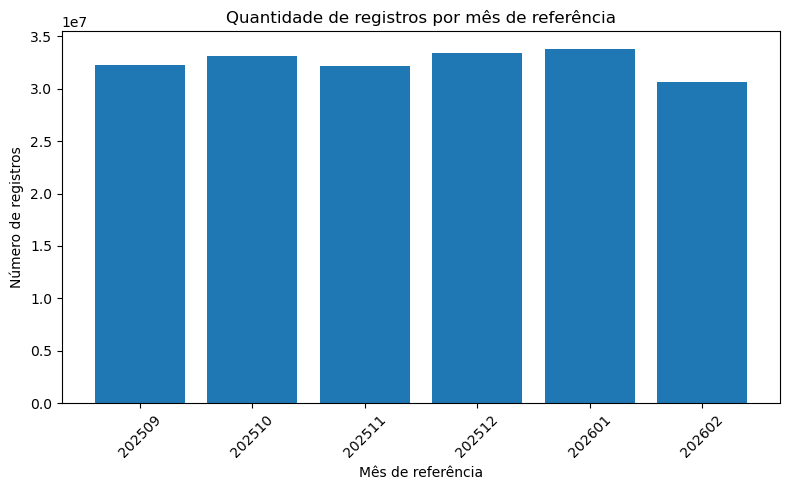

In [11]:
# Preparação para o gráfico
registros_mes_plot = registros_mes.copy()
registros_mes_plot["MES_REFERENCIA"] = registros_mes_plot["MES_REFERENCIA"].astype(str)

plt.figure(figsize=(8, 5))
plt.bar(
    registros_mes_plot["MES_REFERENCIA"],
    registros_mes_plot["total_registros"]
)

plt.title("Quantidade de registros por mês de referência")
plt.xlabel("Mês de referência")
plt.ylabel("Número de registros")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A distribuição de registros por mês apresentou variações compatíveis com a quantidade de dias de cada mês. Meses com 31 dias, como dezembro de 2025 e janeiro de 2026, apresentaram maior volume de registros, enquanto fevereiro de 2026 apresentou menor quantidade por possuir menos dias.

Essa verificação reforça que a consolidação preservou os arquivos mensais de forma consistente, sem indicar perda evidente de registros durante a geração da base Parquet.

### 3. Evolução mensal do consumo agregado

Após validar o volume de registros por mês, foi analisada a evolução mensal das principais métricas de consumo presentes na base: consumo ACL, consumo ajustado e consumo no ponto de conexão.

Essa análise permite observar o comportamento agregado do consumo ao longo dos meses processados e comparar as diferentes formas de contabilização disponíveis no conjunto de dados.

In [12]:
consumo_mensal = consulta(f"""
SELECT
    MES_REFERENCIA,
    SUM(CONSUMO_CARGA_ACL) AS consumo_acl_total,
    SUM(CONSUMO_CARGA_AJUSTADO) AS consumo_ajustado_total,
    SUM(CONSUMO_CARGA_PONTO_CONEXAO) AS consumo_ponto_conexao_total
FROM '{parquet_path.as_posix()}'
GROUP BY MES_REFERENCIA
ORDER BY MES_REFERENCIA
""")

consumo_mensal

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,MES_REFERENCIA,consumo_acl_total,consumo_ajustado_total,consumo_ponto_conexao_total
0,202509,"49,010,436.58","49,010,765.16","48,023,279.52"
1,202510,"51,579,819.52","51,580,243.97","50,577,130.35"
2,202511,"49,582,362.73","49,582,936.36","48,590,957.42"
3,202512,"52,750,012.85","52,750,507.67","51,615,092.00"
4,202601,"53,198,449.33","53,198,901.08","51,912,041.90"
5,202602,"49,926,033.55","49,926,462.34","48,657,856.98"


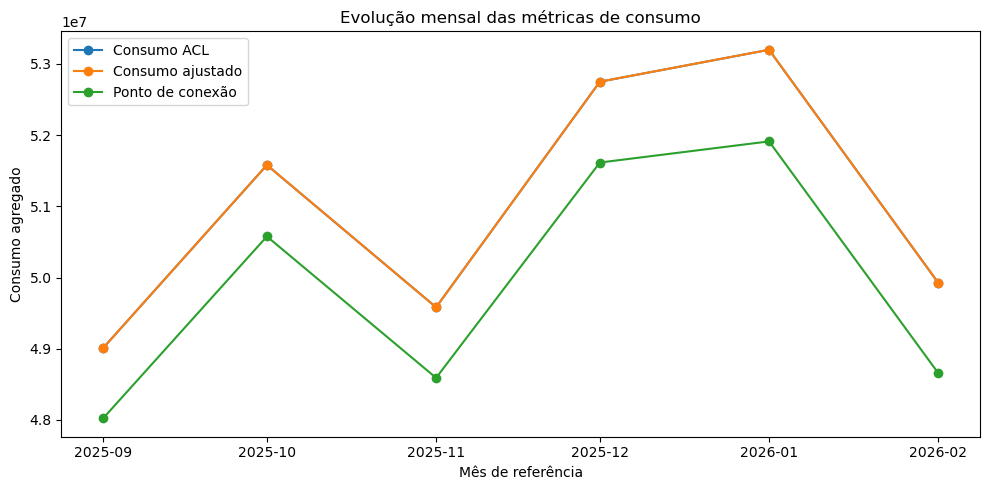

In [13]:
# Preparação para o gráfico
consumo_mensal_plot = consumo_mensal.copy()

consumo_mensal_plot["MES_REFERENCIA"] = pd.to_datetime(
    consumo_mensal_plot["MES_REFERENCIA"].astype(str),
    format="%Y%m"
)

plt.figure(figsize=(10, 5))

plt.plot(
    consumo_mensal_plot["MES_REFERENCIA"],
    consumo_mensal_plot["consumo_acl_total"],
    marker="o",
    label="Consumo ACL"
)

plt.plot(
    consumo_mensal_plot["MES_REFERENCIA"],
    consumo_mensal_plot["consumo_ajustado_total"],
    marker="o",
    label="Consumo ajustado"
)

plt.plot(
    consumo_mensal_plot["MES_REFERENCIA"],
    consumo_mensal_plot["consumo_ponto_conexao_total"],
    marker="o",
    label="Ponto de conexão"
)

plt.title("Evolução mensal das métricas de consumo")
plt.xlabel("Mês de referência")
plt.ylabel("Consumo agregado")
plt.legend()
plt.tight_layout()
plt.show()

Observa-se que o consumo agregado mensal apresenta variação ao longo do período analisado, com maiores valores em dezembro de 2025 e janeiro de 2026. No entanto, como o consumo mensal total é influenciado pela quantidade de dias em cada mês, a comparação direta entre meses pode induzir interpretações equivocadas.

Por esse motivo, a próxima análise calcula o consumo médio diário por mês de referência, permitindo uma comparação mais adequada entre meses com durações diferentes.

### 4. Consumo médio diário por mês de referência

Como os meses possuem quantidades diferentes de dias, a comparação apenas pelo consumo mensal agregado pode não representar adequadamente a intensidade média de consumo.

Para reduzir esse efeito, foi calculado o consumo médio diário em cada mês de referência. Essa análise permite comparar os meses de forma mais equilibrada, considerando o consumo total diário médio em vez do volume mensal acumulado.

In [16]:
consumo_medio_diario_mes = consulta(f"""
WITH consumo_diario AS (
    SELECT
        MES_REFERENCIA,
        DATA,
        SUM(CONSUMO_CARGA_ACL) AS consumo_acl_diario,
        SUM(CONSUMO_CARGA_AJUSTADO) AS consumo_ajustado_diario,
        SUM(CONSUMO_CARGA_PONTO_CONEXAO) AS consumo_ponto_conexao_diario
    FROM '{parquet_path.as_posix()}'
    GROUP BY MES_REFERENCIA, DATA
)

SELECT
    MES_REFERENCIA,
    COUNT(*) AS dias_no_mes,
    AVG(consumo_acl_diario) AS consumo_acl_medio_diario,
    AVG(consumo_ajustado_diario) AS consumo_ajustado_medio_diario,
    AVG(consumo_ponto_conexao_diario) AS consumo_ponto_conexao_medio_diario
FROM consumo_diario
GROUP BY MES_REFERENCIA
ORDER BY MES_REFERENCIA
""")

consumo_medio_diario_mes

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,MES_REFERENCIA,dias_no_mes,consumo_acl_medio_diario,consumo_ajustado_medio_diario,consumo_ponto_conexao_medio_diario
0,202509,30,"1,633,681.22","1,633,692.17","1,600,775.98"
1,202510,31,"1,663,865.15","1,663,878.84","1,631,520.33"
2,202511,30,"1,652,745.42","1,652,764.55","1,619,698.58"
3,202512,31,"1,701,613.32","1,701,629.28","1,665,002.97"
4,202601,31,"1,716,079.01","1,716,093.58","1,674,582.00"
5,202602,28,"1,783,072.63","1,783,087.94","1,737,780.61"


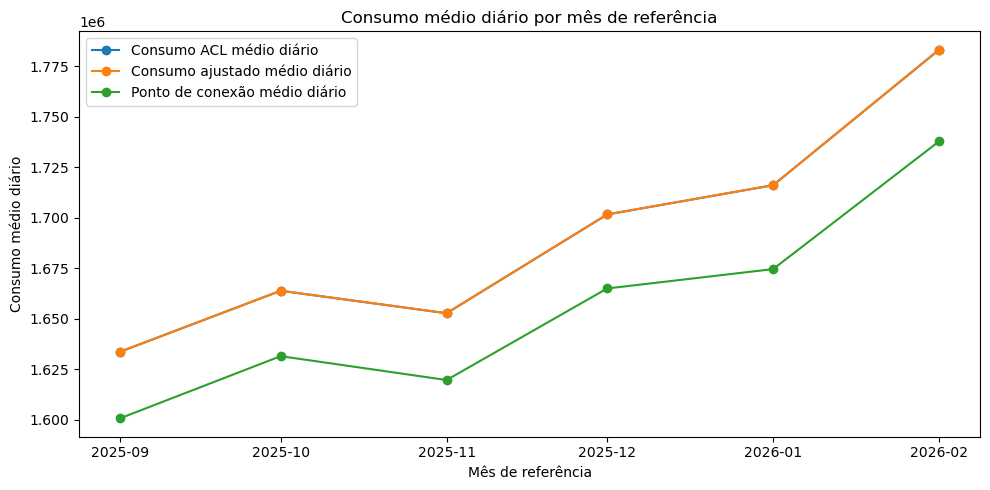

In [15]:
# Preparação para o gráfico
consumo_medio_diario_plot = consumo_medio_diario_mes.copy()

consumo_medio_diario_plot["MES_REFERENCIA"] = pd.to_datetime(
    consumo_medio_diario_plot["MES_REFERENCIA"].astype(str),
    format="%Y%m"
)

plt.figure(figsize=(10, 5))

plt.plot(
    consumo_medio_diario_plot["MES_REFERENCIA"],
    consumo_medio_diario_plot["consumo_acl_medio_diario"],
    marker="o",
    label="Consumo ACL médio diário"
)

plt.plot(
    consumo_medio_diario_plot["MES_REFERENCIA"],
    consumo_medio_diario_plot["consumo_ajustado_medio_diario"],
    marker="o",
    label="Consumo ajustado médio diário"
)

plt.plot(
    consumo_medio_diario_plot["MES_REFERENCIA"],
    consumo_medio_diario_plot["consumo_ponto_conexao_medio_diario"],
    marker="o",
    label="Ponto de conexão médio diário"
)

plt.title("Consumo médio diário por mês de referência")
plt.xlabel("Mês de referência")
plt.ylabel("Consumo médio diário")
plt.legend()
plt.tight_layout()
plt.show()

Após a normalização pelo número de dias de cada mês, observa-se que fevereiro de 2026 apresentou o maior consumo médio diário do período analisado, mesmo tendo o menor volume mensal agregado. Esse resultado mostra que a comparação por consumo total mensal pode esconder diferenças relevantes na intensidade média diária de consumo.

A análise reforça a importância de escolher a métrica adequada antes de interpretar tendências temporais, especialmente quando os períodos comparados possuem durações diferentes.

### 5. Consumo agregado por submercado

Após as análises temporais, foi avaliada a distribuição do consumo entre os submercados do sistema elétrico. Essa análise permite identificar como o consumo ACL agregado se distribui regionalmente na base consolidada.

Além do consumo total, também foram calculados a participação percentual de cada submercado no consumo agregado e o número de cargas distintas associadas a cada região.

In [17]:
consumo_submercado = consulta(f"""
SELECT
    SUBMERCADO,
    SUM(CONSUMO_CARGA_ACL) AS consumo_acl_total,
    100 * SUM(CONSUMO_CARGA_ACL) 
        / SUM(SUM(CONSUMO_CARGA_ACL)) OVER () AS participacao_percentual,
    COUNT(DISTINCT CODIGO_CARGA) AS cargas_distintas,
    COUNT(DISTINCT ESTADO_CARGA) AS estados_distintos
FROM '{parquet_path.as_posix()}'
GROUP BY SUBMERCADO
ORDER BY consumo_acl_total DESC
""")

consumo_submercado

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,SUBMERCADO,consumo_acl_total,participacao_percentual,cargas_distintas,estados_distintos
0,SUDESTE,"171,132,862.74",55.92,25785,11
1,SUL,"53,663,769.88",17.53,11854,5
2,NORDESTE,"48,641,830.23",15.89,6525,8
3,NORTE,"32,608,651.71",10.65,2289,6


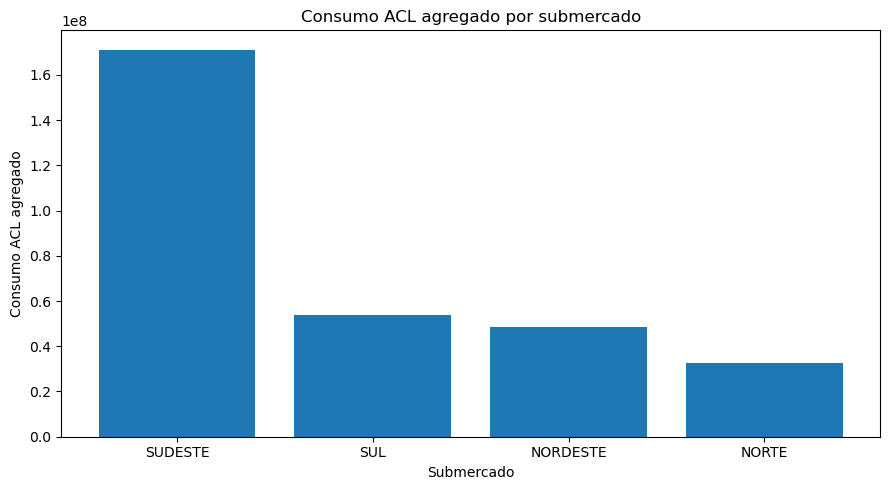

In [18]:
# Preparação para o gráfico
consumo_submercado_plot = consumo_submercado.copy()

plt.figure(figsize=(9, 5))

plt.bar(
    consumo_submercado_plot["SUBMERCADO"],
    consumo_submercado_plot["consumo_acl_total"]
)

plt.title("Consumo ACL agregado por submercado")
plt.xlabel("Submercado")
plt.ylabel("Consumo ACL agregado")
plt.tight_layout()
plt.show()

A análise por submercado mostra uma concentração expressiva do consumo ACL no submercado Sudeste, responsável por 55,92% do consumo agregado no período analisado. Esse submercado também apresenta o maior número de cargas distintas, indicando maior densidade de registros e maior participação na base consolidada.

Os submercados Sul, Nordeste e Norte aparecem em seguida, com participações de 17,53%, 15,89% e 10,65%, respectivamente. Essa distribuição evidencia a relevância da segmentação regional para compreender a estrutura do consumo no Ambiente de Contratação Livre.

### 6. Consumo agregado por estado

Para detalhar a análise regional, o consumo ACL foi agregado por estado da carga. Essa visão permite identificar quais unidades federativas concentram maior participação no consumo total da base consolidada.

Além do consumo total, também foram calculados a participação percentual de cada estado e o número de cargas distintas associadas a cada unidade federativa.

In [21]:
consumo_estado = consulta(f"""
SELECT
    ESTADO_CARGA,
    SUM(CONSUMO_CARGA_ACL) AS consumo_acl_total,
    100 * SUM(CONSUMO_CARGA_ACL)
        / SUM(SUM(CONSUMO_CARGA_ACL)) OVER () AS participacao_percentual,
    COUNT(DISTINCT CODIGO_CARGA) AS cargas_distintas,
    COUNT(DISTINCT SUBMERCADO) AS submercados_associados
FROM '{parquet_path.as_posix()}'
GROUP BY ESTADO_CARGA
ORDER BY consumo_acl_total DESC
""")

consumo_estado

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,ESTADO_CARGA,consumo_acl_total,participacao_percentual,cargas_distintas,submercados_associados
0,SP,"81,726,760.25",26.70,14088,2
1,MG,"32,724,985.19",10.69,3554,1
2,RJ,"26,845,261.20",8.77,3507,1
3,PR,"19,265,215.55",6.29,4431,2
4,SC,"16,415,766.07",5.36,2793,1
5,BA,"15,992,877.07",5.23,2197,1
6,PA,"15,017,905.08",4.91,945,1
7,RS,"14,989,159.97",4.90,4615,1
8,GO,"9,670,175.35",3.16,1176,1
9,PE,"9,438,402.90",3.08,1354,1


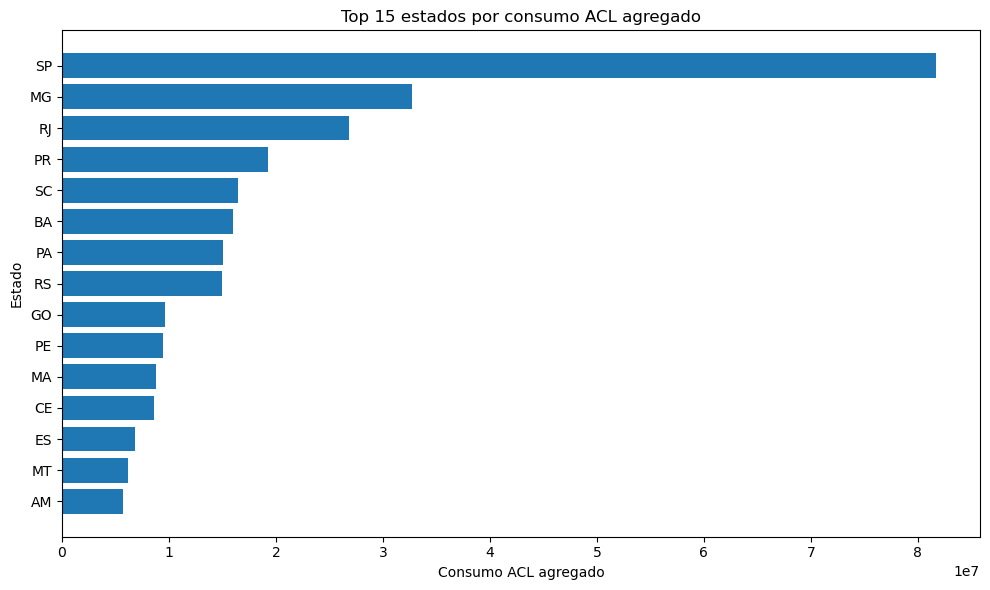

In [22]:
top_estados = consumo_estado.head(15).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    top_estados["ESTADO_CARGA"],
    top_estados["consumo_acl_total"]
)

plt.title("Top 15 estados por consumo ACL agregado")
plt.xlabel("Consumo ACL agregado")
plt.ylabel("Estado")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

A análise por estado mostra que São Paulo concentra a maior participação no consumo ACL agregado da base, com 26,70% do total no período analisado. Em seguida aparecem Minas Gerais, Rio de Janeiro, Paraná, Santa Catarina e Bahia.

Essa distribuição reforça a concentração do consumo em estados com maior densidade econômica e maior número de cargas registradas. A coluna de submercados associados foi mantida como uma verificação adicional, indicando que alguns estados aparecem vinculados a mais de um submercado nos registros da base.

### 7. Perfil médio horário de consumo

Como a base possui registros por período de comercialização, foi analisado o comportamento médio do consumo ao longo do dia.

Para isso, primeiro o consumo foi agregado por data e período de comercialização. Em seguida, foi calculada a média desses totais horários ao longo de todos os dias disponíveis na base. Essa abordagem evita interpretar apenas a média por registro e permite observar uma curva média diária de consumo agregado.

In [23]:
perfil_horario = consulta(f"""
WITH consumo_horario_agregado AS (
    SELECT
        DATA,
        PERIODO_COMERCIALIZACAO,
        SUM(CONSUMO_CARGA_ACL) AS consumo_acl_horario,
        SUM(CONSUMO_CARGA_AJUSTADO) AS consumo_ajustado_horario,
        SUM(CONSUMO_CARGA_PONTO_CONEXAO) AS consumo_ponto_conexao_horario
    FROM '{parquet_path.as_posix()}'
    GROUP BY DATA, PERIODO_COMERCIALIZACAO
)

SELECT
    PERIODO_COMERCIALIZACAO,
    AVG(consumo_acl_horario) AS consumo_acl_medio,
    AVG(consumo_ajustado_horario) AS consumo_ajustado_medio,
    AVG(consumo_ponto_conexao_horario) AS consumo_ponto_conexao_medio
FROM consumo_horario_agregado
GROUP BY PERIODO_COMERCIALIZACAO
ORDER BY PERIODO_COMERCIALIZACAO
""")

perfil_horario

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,PERIODO_COMERCIALIZACAO,consumo_acl_medio,consumo_ajustado_medio,consumo_ponto_conexao_medio
0,0,"75,639.19","75,639.74","74,058.73"
1,1,"72,342.57","72,343.11","70,785.00"
2,2,"70,072.70","70,073.26","68,522.32"
3,3,"68,683.03","68,683.60","67,130.28"
4,4,"68,244.04","68,244.63","66,686.39"
5,5,"67,932.68","67,933.27","66,369.24"
6,6,"66,304.72","66,305.34","64,760.27"
7,7,"63,375.26","63,375.90","61,845.73"
8,8,"60,252.80","60,253.49","58,783.53"
9,9,"56,906.53","56,907.24","55,590.21"


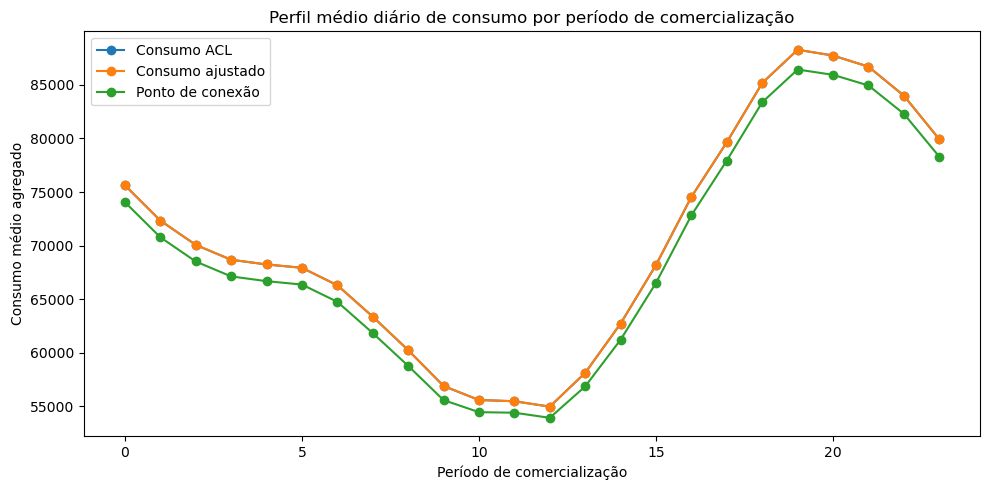

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    perfil_horario["PERIODO_COMERCIALIZACAO"],
    perfil_horario["consumo_acl_medio"],
    marker="o",
    label="Consumo ACL"
)

plt.plot(
    perfil_horario["PERIODO_COMERCIALIZACAO"],
    perfil_horario["consumo_ajustado_medio"],
    marker="o",
    label="Consumo ajustado"
)

plt.plot(
    perfil_horario["PERIODO_COMERCIALIZACAO"],
    perfil_horario["consumo_ponto_conexao_medio"],
    marker="o",
    label="Ponto de conexão"
)

plt.title("Perfil médio diário de consumo por período de comercialização")
plt.xlabel("Período de comercialização")
plt.ylabel("Consumo médio agregado")
plt.legend()
plt.tight_layout()
plt.show()

A curva média diária de consumo mostra um comportamento intradiário bem definido. Observa-se uma redução gradual do consumo médio agregado ao longo da manhã, com valores mínimos próximos aos períodos 10 a 12, seguida por uma retomada ao longo da tarde e um pico mais acentuado entre os períodos 18 e 20.

Esse resultado evidencia que a base consolidada preserva adequadamente a granularidade horária dos dados, permitindo análises não apenas mensais e regionais, mas também do padrão médio de consumo ao longo do dia.

### 8. Diferença entre consumo ajustado e consumo no ponto de conexão

Além da análise do consumo agregado, foi avaliada a diferença entre o consumo ajustado e o consumo no ponto de conexão ao longo dos meses de referência.

Essa comparação permite verificar a magnitude da diferença entre duas métricas relevantes presentes na base e identificar se essa distância relativa se mantém estável ou varia ao longo do período analisado.

In [25]:
diferenca_consumo = consulta(f"""
SELECT
    MES_REFERENCIA,
    SUM(CONSUMO_CARGA_AJUSTADO) AS consumo_ajustado_total,
    SUM(CONSUMO_CARGA_PONTO_CONEXAO) AS consumo_ponto_conexao_total,
    SUM(CONSUMO_CARGA_AJUSTADO - CONSUMO_CARGA_PONTO_CONEXAO) AS diferenca_total,
    100 * SUM(CONSUMO_CARGA_AJUSTADO - CONSUMO_CARGA_PONTO_CONEXAO)
        / NULLIF(SUM(CONSUMO_CARGA_AJUSTADO), 0) AS diferenca_percentual
FROM '{parquet_path.as_posix()}'
GROUP BY MES_REFERENCIA
ORDER BY MES_REFERENCIA
""")

diferenca_consumo

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,MES_REFERENCIA,consumo_ajustado_total,consumo_ponto_conexao_total,diferenca_total,diferenca_percentual
0,202509,"49,010,765.16","48,023,279.52","987,485.65",2.01
1,202510,"51,580,243.97","50,577,130.35","1,003,113.62",1.94
2,202511,"49,582,936.36","48,590,957.42","991,978.94",2.00
3,202512,"52,750,507.67","51,615,092.00","1,135,415.68",2.15
4,202601,"53,198,901.08","51,912,041.90","1,286,859.19",2.42
5,202602,"49,926,462.34","48,657,856.98","1,268,605.36",2.54


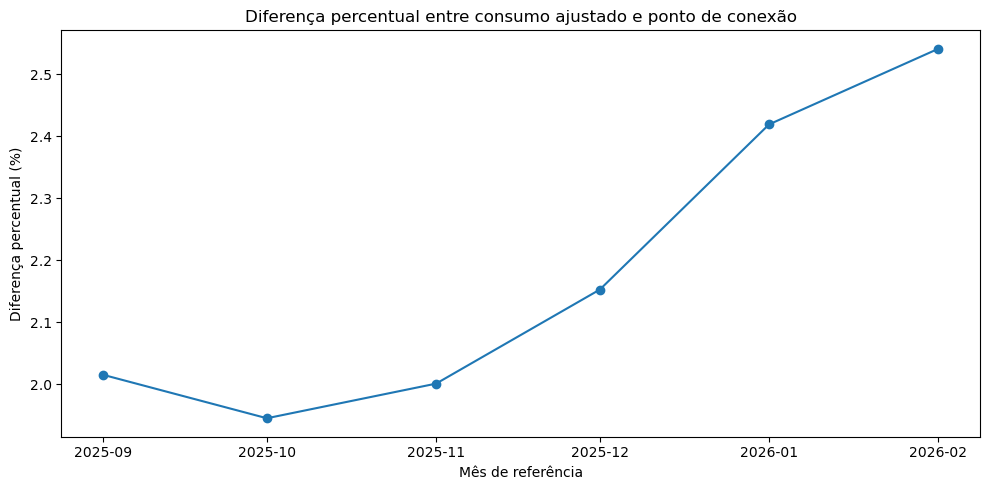

In [26]:
diferenca_consumo_plot = diferenca_consumo.copy()

diferenca_consumo_plot["MES_REFERENCIA"] = pd.to_datetime(
    diferenca_consumo_plot["MES_REFERENCIA"].astype(str),
    format="%Y%m"
)

plt.figure(figsize=(10, 5))

plt.plot(
    diferenca_consumo_plot["MES_REFERENCIA"],
    diferenca_consumo_plot["diferenca_percentual"],
    marker="o"
)

plt.title("Diferença percentual entre consumo ajustado e ponto de conexão")
plt.xlabel("Mês de referência")
plt.ylabel("Diferença percentual (%)")
plt.tight_layout()
plt.show()

A comparação entre o consumo ajustado e o consumo no ponto de conexão mostra que a diferença percentual entre essas métricas permaneceu próxima de 2% entre setembro e novembro de 2025, mas aumentou nos meses seguintes, atingindo 2,42% em janeiro de 2026 e 2,54% em fevereiro de 2026.

Esse resultado indica que, embora as curvas de consumo agregado apresentem comportamento semelhante, a diferença relativa entre as métricas não é completamente constante ao longo do período analisado. Essa análise reforça a importância de comparar as diferentes definições de consumo disponíveis na base antes de selecionar uma métrica principal para estudos posteriores.

### 9. Consumo por classe de perfil de agente

Após as análises temporais e regionais, foi avaliada a distribuição do consumo ACL entre as classes de perfil de agente presentes na base.

Essa análise permite identificar quais categorias de agentes concentram maior participação no consumo agregado, contribuindo para uma leitura mais orientada ao mercado.

In [27]:
consumo_classe_perfil = consulta(f"""
SELECT
    CLASSE_PERFIL_AGENTE,
    SUM(CONSUMO_CARGA_ACL) AS consumo_acl_total,
    100 * SUM(CONSUMO_CARGA_ACL)
        / SUM(SUM(CONSUMO_CARGA_ACL)) OVER () AS participacao_percentual,
    COUNT(DISTINCT CODIGO_PERFIL_AGENTE) AS perfis_distintos,
    COUNT(DISTINCT CODIGO_CARGA) AS cargas_distintas
FROM '{parquet_path.as_posix()}'
GROUP BY CLASSE_PERFIL_AGENTE
ORDER BY consumo_acl_total DESC
""")

consumo_classe_perfil

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,CLASSE_PERFIL_AGENTE,consumo_acl_total,participacao_percentual,perfis_distintos,cargas_distintas
0,Distribuidor,"183,622,521.64",60.00,100,144
1,Consumidor Livre,"95,943,513.48",31.35,12435,14608
2,Consumidor Especial,"15,370,723.19",5.02,6973,31657
3,Autoprodutor,"10,817,084.48",3.53,157,251
4,Exportador,"293,271.78",0.10,15,15


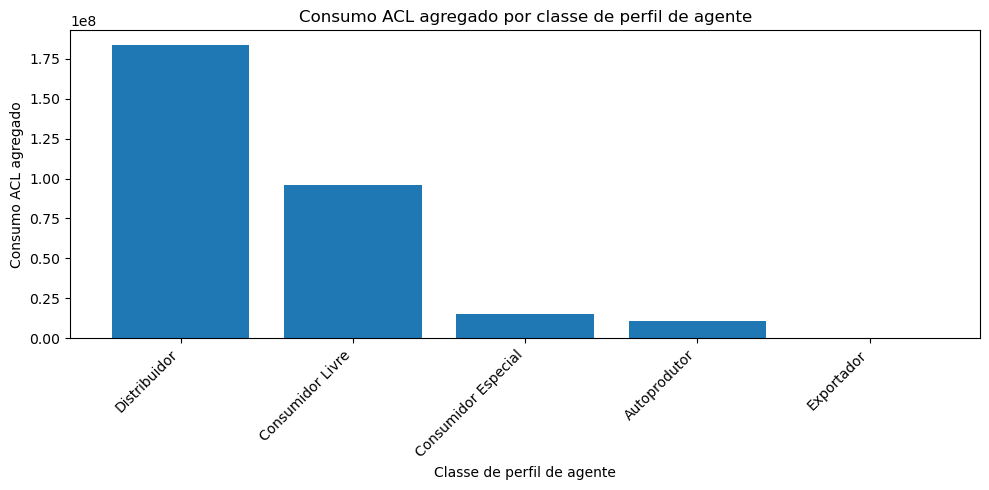

In [28]:
plt.figure(figsize=(10, 5))

plt.bar(
    consumo_classe_perfil["CLASSE_PERFIL_AGENTE"],
    consumo_classe_perfil["consumo_acl_total"]
)

plt.title("Consumo ACL agregado por classe de perfil de agente")
plt.xlabel("Classe de perfil de agente")
plt.ylabel("Consumo ACL agregado")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 10. Consumo médio por dia da semana

Além da análise horária, foi avaliado o comportamento do consumo médio diário ao longo dos dias da semana.

Para isso, o consumo ACL foi primeiro agregado por data. Em seguida, cada data foi classificada de acordo com o dia da semana, permitindo comparar o consumo médio observado entre segunda-feira, terça-feira, quarta-feira, quinta-feira, sexta-feira, sábado e domingo.

In [29]:
consumo_dia_semana = consulta(f"""
WITH consumo_diario AS (
    SELECT
        DATA,
        SUM(CONSUMO_CARGA_ACL) AS consumo_acl_diario
    FROM '{parquet_path.as_posix()}'
    GROUP BY DATA
),

dias_classificados AS (
    SELECT
        DATA,
        consumo_acl_diario,
        EXTRACT('dow' FROM DATA) AS numero_dia_semana,
        CASE EXTRACT('dow' FROM DATA)
            WHEN 0 THEN 'Domingo'
            WHEN 1 THEN 'Segunda-feira'
            WHEN 2 THEN 'Terça-feira'
            WHEN 3 THEN 'Quarta-feira'
            WHEN 4 THEN 'Quinta-feira'
            WHEN 5 THEN 'Sexta-feira'
            WHEN 6 THEN 'Sábado'
        END AS dia_semana
    FROM consumo_diario
)

SELECT
    numero_dia_semana,
    dia_semana,
    COUNT(*) AS quantidade_dias,
    AVG(consumo_acl_diario) AS consumo_acl_medio_diario,
    MIN(consumo_acl_diario) AS menor_consumo_diario,
    MAX(consumo_acl_diario) AS maior_consumo_diario
FROM dias_classificados
GROUP BY numero_dia_semana, dia_semana
ORDER BY numero_dia_semana
""")

consumo_dia_semana

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,numero_dia_semana,dia_semana,quantidade_dias,consumo_acl_medio_diario,menor_consumo_diario,maior_consumo_diario
0,0,Domingo,25,"1,506,708.10","1,395,422.69","1,601,049.40"
1,1,Segunda-feira,26,"1,727,578.48","1,571,377.64","1,835,412.51"
2,2,Terça-feira,26,"1,749,870.61","1,582,662.24","1,876,826.94"
3,3,Quarta-feira,26,"1,741,758.90","1,581,577.25","1,885,718.71"
4,4,Quinta-feira,26,"1,727,654.15","1,454,791.22","1,903,273.87"
5,5,Sexta-feira,26,"1,750,760.94","1,612,797.75","1,905,359.46"
6,6,Sábado,26,"1,624,661.98","1,481,928.89","1,728,704.58"


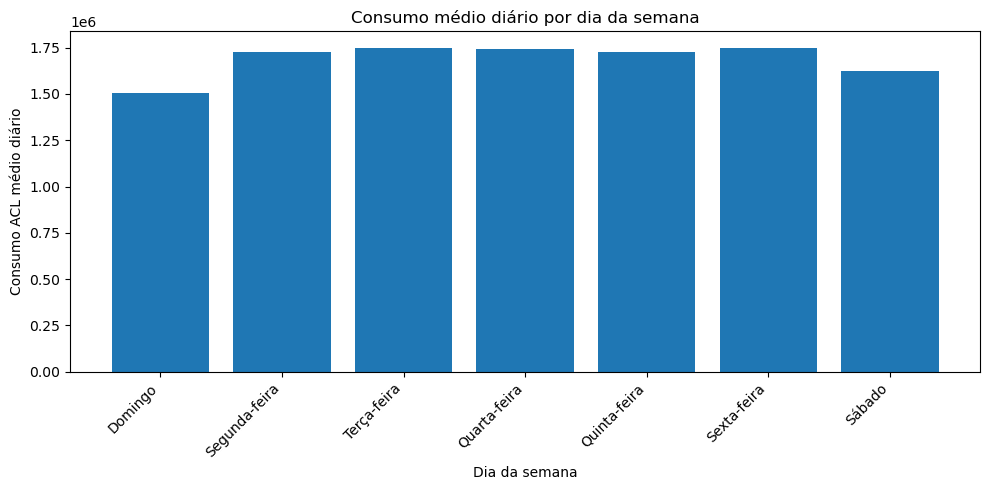

In [30]:
plt.figure(figsize=(10, 5))

plt.bar(
    consumo_dia_semana["dia_semana"],
    consumo_dia_semana["consumo_acl_medio_diario"]
)

plt.title("Consumo médio diário por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Consumo ACL médio diário")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Síntese dos principais insights

As análises exploratórias realizadas a partir da base Parquet consolidada permitiram caracterizar o conjunto de dados em diferentes dimensões: temporal, regional, horária e por perfil de agente.

Os principais resultados observados foram:

- A base consolidada contém 195.448.968 registros, cobrindo seis meses de dados horários, de setembro de 2025 a fevereiro de 2026.
- A distribuição de registros por mês foi compatível com a quantidade de dias de cada mês, sem indicar perda evidente de dados na consolidação.
- A análise mensal mostrou que o consumo agregado é influenciado pela duração do mês, tornando necessária a comparação por consumo médio diário.
- Após a normalização diária, fevereiro de 2026 apresentou o maior consumo médio diário do período analisado.
- O submercado Sudeste concentrou a maior participação no consumo ACL agregado, com 55,92% do total.
- São Paulo foi o estado com maior participação no consumo ACL, representando 26,70% do total analisado.
- O perfil médio horário revelou um padrão intradiário bem definido, com menor consumo no meio do dia e maior consumo no início da noite.
- A diferença percentual entre consumo ajustado e consumo no ponto de conexão aumentou ao longo do período, passando de aproximadamente 2,01% em setembro de 2025 para 2,54% em fevereiro de 2026.
- A classe Distribuidor concentrou a maior parcela do consumo ACL agregado, apesar de apresentar menor número de cargas distintas em comparação com consumidores livres e especiais.
- A análise por dia da semana mostrou menor consumo médio aos fins de semana e maior consumo médio nos dias úteis.

Em conjunto, essas análises mostram que a etapa de consolidação dos CSVs em Parquet não apenas reduziu o atrito técnico no tratamento dos dados, mas também criou uma base adequada para investigações analíticas sobre consumo de energia no Ambiente de Contratação Livre.